<a href="https://colab.research.google.com/github/Safiyabegum52/Simple-registration-form-/blob/main/Employee_promotion_prediction_using_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Employee Promotion Prediction Using ML**

**AIM**  

The Employee Promotion Prediction using Machine Learning project is to build a model that predicts whether an employee is likely to be promoted, helping organizations make fair, data‑driven, and efficient HR decisions.

**OBJECTIVE:**

**Primary Objective:**
Develop a machine learning model that predicts whether an employee is likely to be promoted based on performance, experience, and HR‑related factors.

**Secondary Objective**:
Provide data‑driven insights to support fair and transparent promotion decisions, reducing bias and improving efficiency in HR processes.

---



DATASET LOADING

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


IMPORT LIBRARIES

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

LOAD DATASET

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/project 1/promotion.csv")
#Import dataset using Pandas.
# Read CSV file

DESCRIPTION:

This project applies machine learning techniques to predict employee promotions by analyzing historical HR data such as performance ratings, training hours, tenure, and awards. The system is designed to classify employees into promotion‑eligible or not, offering HR managers a reliable, data‑driven tool to support decision‑making. By automating the evaluation process, the project reduces bias, saves time, and enhances transparency in workforce management.

DATA COLLECTION


In [ ]:
df
#Display all data

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,0,49.0,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,60.0,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,50.0,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,50.0,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,73.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
54803,3030,Technology,region_14,Bachelor's,m,sourcing,1,48,3.0,17,0,78.0,0
54804,74592,Operations,region_27,Master's & above,f,other,1,37,2.0,6,0,56.0,0
54805,13918,Analytics,region_1,Bachelor's,m,other,1,27,5.0,3,0,79.0,0
54806,13614,Sales & Marketing,region_9,NaN,m,sourcing,1,29,1.0,2,0,NaN,0


In [ ]:
df.head
# Display first 5 rows

<bound method NDFrame.head of        employee_id         department     region         education gender  \
0            65438  Sales & Marketing   region_7  Master's & above      f   
1            65141         Operations  region_22        Bachelor's      m   
2             7513  Sales & Marketing  region_19        Bachelor's      m   
3             2542  Sales & Marketing  region_23        Bachelor's      m   
4            48945         Technology  region_26        Bachelor's      m   
...            ...                ...        ...               ...    ...   
54803         3030         Technology  region_14        Bachelor's      m   
54804        74592         Operations  region_27  Master's & above      f   
54805        13918          Analytics   region_1        Bachelor's      m   
54806        13614  Sales & Marketing   region_9               NaN      m   
54807        51526                 HR  region_22        Bachelor's      m   

      recruitment_channel  no_of_trainings  age  previous_year_rating  \
0                sourcing                1   35                   5.0   
1                   other                1   30                   5.0   
2                sourcing                1   34                   3.0   
3                   other                2   39                   1.0   
4                   other                1   45                   3.0   
...                   ...              ...  ...                   ...   
54803            sourcing                1   48                   3.0   
54804               other                1   37                   2.0   
54805               other                1   27                   5.0   
54806            sourcing                1   29                   1.0   
54807               other                1   27                   1.0   

       length_of_service  awards_won  avg_training_score  is_promoted  
0                      8           0                49.0            0  
1                      4           0                60.0            0  
2                      7           0                50.0            0  
3                     10           0                50.0            0  
4                      2           0                73.0            0  
...                  ...         ...                 ...          ...  
54803                 17           0                78.0            0  
54804                  6           0                56.0            0  
54805                  3           0                79.0            0  
54806                  2           0                 NaN            0  
54807                  5           0                49.0            0  

[54808 rows x 13 columns]>

In [ ]:
df.tail
# Display last 5 rows

<bound method NDFrame.tail of        employee_id         department     region         education gender  \
0            65438  Sales & Marketing   region_7  Master's & above      f   
1            65141         Operations  region_22        Bachelor's      m   
2             7513  Sales & Marketing  region_19        Bachelor's      m   
3             2542  Sales & Marketing  region_23        Bachelor's      m   
4            48945         Technology  region_26        Bachelor's      m   
...            ...                ...        ...               ...    ...   
54803         3030         Technology  region_14        Bachelor's      m   
54804        74592         Operations  region_27  Master's & above      f   
54805        13918          Analytics   region_1        Bachelor's      m   
54806        13614  Sales & Marketing   region_9               NaN      m   
54807        51526                 HR  region_22        Bachelor's      m   

      recruitment_channel  no_of_trainings  age  previous_year_rating  \
0                sourcing                1   35                   5.0   
1                   other                1   30                   5.0   
2                sourcing                1   34                   3.0   
3                   other                2   39                   1.0   
4                   other                1   45                   3.0   
...                   ...              ...  ...                   ...   
54803            sourcing                1   48                   3.0   
54804               other                1   37                   2.0   
54805               other                1   27                   5.0   
54806            sourcing                1   29                   1.0   
54807               other                1   27                   1.0   

       length_of_service  awards_won  avg_training_score  is_promoted  
0                      8           0                49.0            0  
1                      4           0                60.0            0  
2                      7           0                50.0            0  
3                     10           0                50.0            0  
4                      2           0                73.0            0  
...                  ...         ...                 ...          ...  
54803                 17           0                78.0            0  
54804                  6           0                56.0            0  
54805                  3           0                79.0            0  
54806                  2           0                 NaN            0  
54807                  5           0                49.0            0  

[54808 rows x 13 columns]>

In [ ]:
df.describe
# Display statistical summary of the dataset

<bound method NDFrame.describe of        employee_id         department     region         education gender  \
0            65438  Sales & Marketing   region_7  Master's & above      f   
1            65141         Operations  region_22        Bachelor's      m   
2             7513  Sales & Marketing  region_19        Bachelor's      m   
3             2542  Sales & Marketing  region_23        Bachelor's      m   
4            48945         Technology  region_26        Bachelor's      m   
...            ...                ...        ...               ...    ...   
54803         3030         Technology  region_14        Bachelor's      m   
54804        74592         Operations  region_27  Master's & above      f   
54805        13918          Analytics   region_1        Bachelor's      m   
54806        13614  Sales & Marketing   region_9               NaN      m   
54807        51526                 HR  region_22        Bachelor's      m   

      recruitment_channel  no_of_trainings  age  previous_year_rating  \
0                sourcing                1   35                   5.0   
1                   other                1   30                   5.0   
2                sourcing                1   34                   3.0   
3                   other                2   39                   1.0   
4                   other                1   45                   3.0   
...                   ...              ...  ...                   ...   
54803            sourcing                1   48                   3.0   
54804               other                1   37                   2.0   
54805               other                1   27                   5.0   
54806            sourcing                1   29                   1.0   
54807               other                1   27                   1.0   

       length_of_service  awards_won  avg_training_score  is_promoted  
0                      8           0                49.0            0  
1                      4           0                60.0            0  
2                      7           0                50.0            0  
3                     10           0                50.0            0  
4                      2           0                73.0            0  
...                  ...         ...                 ...          ...  
54803                 17           0                78.0            0  
54804                  6           0                56.0            0  
54805                  3           0                79.0            0  
54806                  2           0                 NaN            0  
54807                  5           0                49.0            0  

[54808 rows x 13 columns]>

DATA CLEANING

In [ ]:
# Check missing values
print("\nMissing Values")
print(df.isnull().sum())



Missing Values
employee_id                0
department                 0
region                     0
education               2409
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
previous_year_rating    4124
length_of_service          0
awards_won                 0
avg_training_score      2560
is_promoted                0
dtype: int64


In [ ]:
print(df.isnull().sum()[df.isnull().sum() > 0])

education               2409
previous_year_rating    4124
avg_training_score      2560
dtype: int64


In [ ]:
df_cleaned = df.dropna(inplace=True)
display(df_cleaned)

None

In [ ]:
print(df.isnull().sum())

employee_id             0
department              0
region                  0
education               0
gender                  0
recruitment_channel     0
no_of_trainings         0
age                     0
previous_year_rating    0
length_of_service       0
awards_won              0
avg_training_score      0
is_promoted             0
dtype: int64


IMPORT LIBRARIES MATPLOTLIB,SEABORN,PYPLOT

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import plotly.express as px
from plotly.offline import init_notebook_mode
init_notebook_mode(connected=True)

SEABORN

In [ ]:
Bar graph - promotion count by gender

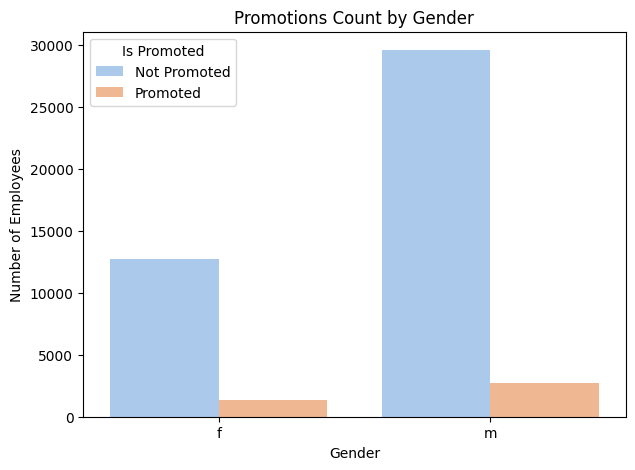

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(7, 5))
sns.countplot(x='gender', hue='is_promoted', data=df, palette='pastel')
plt.title('Promotions Count by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Employees')
plt.legend(title='Is Promoted', labels=['Not Promoted', 'Promoted'])
plt.show()


Count plot -count of employees by number of trainings

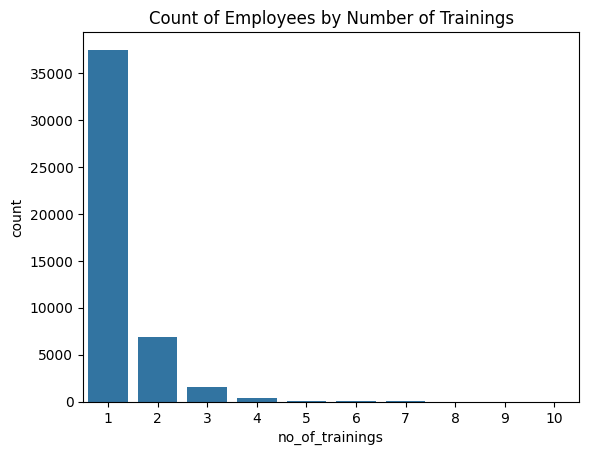

In [ ]:
sns.countplot(x='no_of_trainings', data=df)
plt.title('Count of Employees by Number of Trainings')
plt.show()

Scatter plot -Age vs Length of service

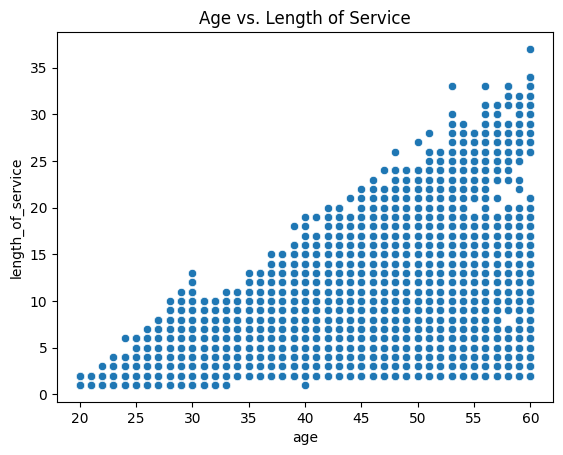

In [ ]:
sns.scatterplot(x='age', y='length_of_service', data=df)
plt.title('Age vs. Length of Service')
plt.show()

PLOTLY

In [ ]:
import plotly.io as pio
pio.renderers.default = 'colab'

PLOTLY GRAPH -Age and length of service distribution

In [ ]:
fig_box = px.box(df, y='age', x='length_of_service', color='gender',
                 title='Age and Length of Service Distribution by Gender (Plotly)',
                 template='plotly_dark')
fig_box.show()

BAR GRAPH -Average training score by department

In [ ]:
bar_data = df.groupby('department')['avg_training_score'].mean().reset_index()

fig = px.bar(
    bar_data,
    x='department',
    y='avg_training_score',
    title='Average Training Score by Department'
)

fig.show()

LINE GRAPH -Age vs average training score

In [ ]:
line_data = df.groupby('age')['avg_training_score'].mean().reset_index()

fig = px.line(
    line_data,
    x='age',
    y='avg_training_score',
    title='Age vs Average Training Score'
)

fig.show()


HISTOGRAM -Age distribution

In [ ]:
fig = px.histogram(
    df,
    x='age',
    nbins=10,
    title='Age Distribution'
)

fig.show()


BOX PLOT -box plot of training scores

In [ ]:
fig = px.box(
    df,
    y='avg_training_score',
    title='Box Plot of Training Scores'
)

fig.show()


PIE CHART -Promotion status

In [ ]:
pie_data = df['is_promoted'].value_counts().reset_index()
pie_data.columns = ['Promotion Status', 'Count']

fig = px.pie(
    pie_data,
    names='Promotion Status',
    values='Count',
    title='Promotion Status'
)

fig.show()

MATPLOTLIB GRAPH


BAG GRAPH - Reqiurement channel vs number of employees

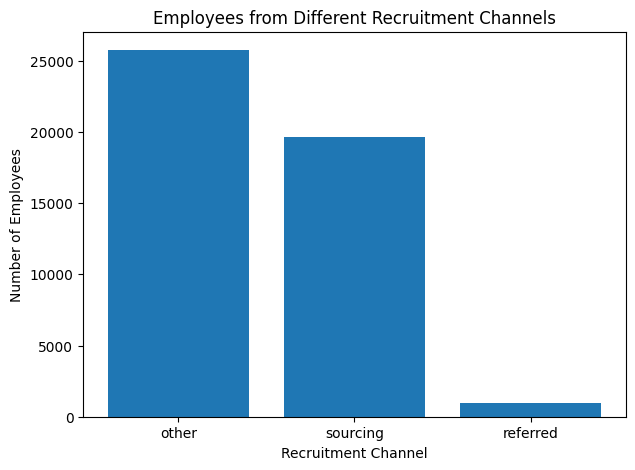

In [ ]:
channel_count = df['recruitment_channel'].value_counts()

plt.figure(figsize=(7,5))
plt.bar(channel_count.index, channel_count.values)
plt.title("Employees from Different Recruitment Channels")
plt.xlabel("Recruitment Channel")
plt.ylabel("Number of Employees")
plt.show()

LINE GRAPH- Service years vs traing performances

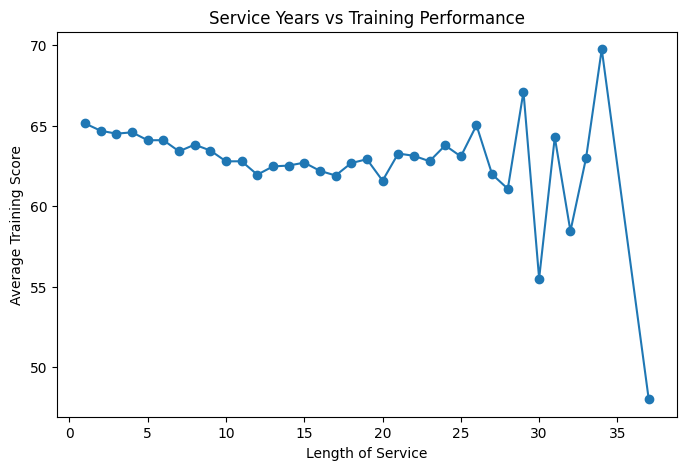

In [ ]:
service_kpi = df.groupby('length_of_service')['avg_training_score'].mean()

plt.figure(figsize=(8,5))
plt.plot(service_kpi.index, service_kpi.values, marker='o')
plt.title("Service Years vs Training Performance")
plt.xlabel("Length of Service")
plt.ylabel("Average Training Score")
plt.show()


HISTOGRAM -Distribution of previous year ratings

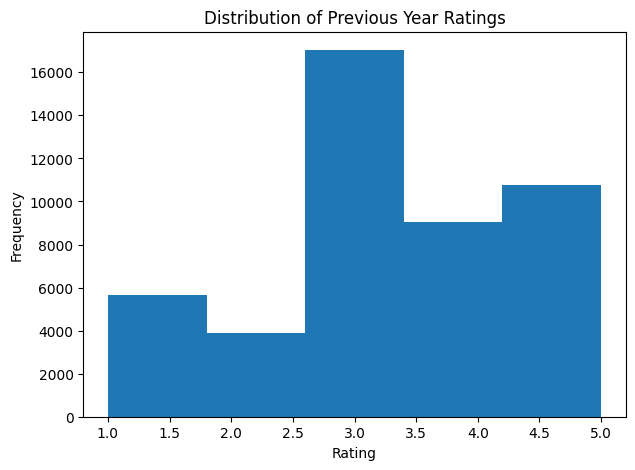

In [ ]:
plt.figure(figsize=(7,5))
plt.hist(df['previous_year_rating'].dropna(), bins=5)

plt.title("Distribution of Previous Year Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

BOX PLOT-Employee age spread

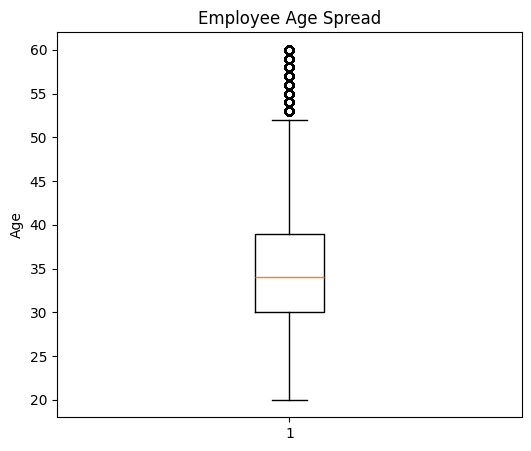

In [ ]:
plt.figure(figsize=(6,5))
plt.boxplot(df['age'])

plt.title("Employee Age Spread")
plt.ylabel("Age")
plt.show()

PIE CHART- Employee gender distribution

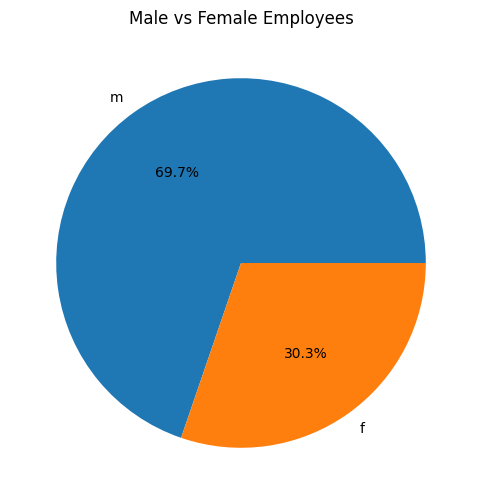

In [ ]:
gender_count = df['gender'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    gender_count.values,
    labels=gender_count.index,
    autopct='%1.1f%%'
)

plt.title("Male vs Female Employees")
plt.show()

In [ ]:
col=['department','region','recruitment_channel','education']


In [ ]:
for i in col:
    print(i)

department
region
recruitment_channel
education


In [ ]:
print(df[i].nunique())

3


In [ ]:
print()



In [ ]:
col=['department','region','recruitment_channel','education']

for i in col:
    print(i)
    print(df[i].unique())
    print(df[i].nunique())
    print()

department
['Sales & Marketing' 'Operations' 'Technology' 'Analytics' 'R&D'
 'Procurement' 'Finance' 'HR' 'Legal']
9

region
['region_7' 'region_22' 'region_19' 'region_23' 'region_26' 'region_2'
 'region_20' 'region_34' 'region_1' 'region_4' 'region_29' 'region_31'
 'region_15' 'region_14' 'region_11' 'region_5' 'region_28' 'region_17'
 'region_13' 'region_16' 'region_25' 'region_10' 'region_27' 'region_30'
 'region_12' 'region_21' 'region_32' 'region_6' 'region_33' 'region_8'
 'region_24' 'region_3' 'region_9' 'region_18']
34

recruitment_channel
['sourcing' 'other' 'referred']
3

education
["Master's & above" "Bachelor's" 'Below Secondary']
3



In [ ]:
df.drop('employee_id',axis=1,inplace=True)
df.drop('region',axis=1,inplace=True)


In [ ]:

df.head()


,department,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won,avg_training_score,is_promoted
0,Sales & Marketing,Master's & above,f,sourcing,1,35,5.0,8,0,49.0,0
1,Operations,Bachelor's,m,other,1,30,5.0,4,0,60.0,0
2,Sales & Marketing,Bachelor's,m,sourcing,1,34,3.0,7,0,50.0,0
3,Sales & Marketing,Bachelor's,m,other,2,39,1.0,10,0,50.0,0
4,Technology,Bachelor's,m,other,1,45,3.0,2,0,73.0,0


In [ ]:

from sklearn.preprocessing import LabelEncoder
l=LabelEncoder()
for i in df.columns:
    if df[i].dtype == 'object':
        df[i]=l.fit_transform(df[i])

# The 'object' data type columns are transformed as follows







In [ ]:

x=df.drop('is_promoted',axis=1)
y=df['is_promoted']
x_cols = x.columns # Capture column names for scaling

In [ ]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.30)

In [ ]:
df

,department,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won,avg_training_score,is_promoted
0,7,2,0,2,1,35,5.0,8,0,49.0,0
1,4,0,1,0,1,30,5.0,4,0,60.0,0
2,7,0,1,2,1,34,3.0,7,0,50.0,0
3,7,0,1,0,2,39,1.0,10,0,50.0,0
4,8,0,1,0,1,45,3.0,2,0,73.0,0
...,...,...,...,...,...,...,...,...,...,...,...
54802,7,0,1,0,2,31,1.0,2,0,49.0,0
54803,8,0,1,2,1,48,3.0,17,0,78.0,0
54804,4,2,0,0,1,37,2.0,6,0,56.0,0
54805,0,0,1,0,1,27,5.0,3,0,79.0,0


In [ ]:
df.head()

,department,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won,avg_training_score,is_promoted
0,7,2,0,2,1,35,5.0,8,0,49.0,0
1,4,0,1,0,1,30,5.0,4,0,60.0,0
2,7,0,1,2,1,34,3.0,7,0,50.0,0
3,7,0,1,0,2,39,1.0,10,0,50.0,0
4,8,0,1,0,1,45,3.0,2,0,73.0,0


In [ ]:
df.tail()

,department,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won,avg_training_score,is_promoted
54802,7,0,1,0,2,31,1.0,2,0,49.0,0
54803,8,0,1,2,1,48,3.0,17,0,78.0,0
54804,4,2,0,0,1,37,2.0,6,0,56.0,0
54805,0,0,1,0,1,27,5.0,3,0,79.0,0
54807,2,0,1,0,1,27,1.0,5,0,49.0,0


In [ ]:
df.describe()

,department,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won,avg_training_score,is_promoted
count,46380.000000,46380.000000,46380.000000,46380.000000,46380.000000,46380.000000,46380.00000,46380.000000,46380.000000,46380.000000,46380.000000
mean,5.000819,0.621108,0.697434,0.868650,1.254506,35.572402,3.33232,6.307956,0.023502,63.927577,0.087775
std,2.506680,0.920557,0.459374,0.980654,0.607985,7.526501,1.25897,4.202143,0.151492,13.425576,0.282970
min,0.000000,0.000000,0.000000,0.000000,1.000000,20.000000,1.00000,1.000000,0.000000,39.000000,0.000000
25%,4.000000,0.000000,0.000000,0.000000,1.000000,30.000000,3.00000,3.000000,0.000000,51.000000,0.000000
50%,5.000000,0.000000,1.000000,0.000000,1.000000,34.000000,3.00000,5.000000,0.000000,60.000000,0.000000
75%,7.000000,2.000000,1.000000,2.000000,1.000000,39.000000,4.00000,8.000000,0.000000,77.000000,0.000000
max,8.000000,2.000000,1.000000,2.000000,10.000000,60.000000,5.00000,37.000000,1.000000,99.000000,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46380 entries, 0 to 54807
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   department            46380 non-null  int64  
 1   education             46380 non-null  int64  
 2   gender                46380 non-null  int64  
 3   recruitment_channel   46380 non-null  int64  
 4   no_of_trainings       46380 non-null  int64  
 5   age                   46380 non-null  int64  
 6   previous_year_rating  46380 non-null  float64
 7   length_of_service     46380 non-null  int64  
 8   awards_won            46380 non-null  int64  
 9   avg_training_score    46380 non-null  float64
 10  is_promoted           46380 non-null  int64  
dtypes: float64(2), int64(9)
memory usage: 4.2 MB


In [ ]:
from sklearn.preprocessing import MinMaxScaler
mms=MinMaxScaler(feature_range=(0,1))
x_train=mms.fit_transform(xtrain)
x_test=mms.transform(xtest) # Use transform, not fit_transform, for test set

# Convert back to DataFrame with original column names
x_train=pd.DataFrame(xtrain, columns=x_cols)
x_test=pd.DataFrame(xtest, columns=x_cols)

IMPORTING MACHINE LEARNING ALGORITHM

LOGISTIC REGRESSION,DECISSION TREE,RANDOM FOREST

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

lr=LogisticRegression()
dc=DecisionTreeClassifier()
rf=RandomForestClassifier()

model=[lr,dc,rf]

for models in model:
    models.fit(xtrain,ytrain)  #80in , 80op == 80%dATA

    ypred=models.predict(xtest)  #30 IN


    print('Model :',models)
    print('-------------------------------------------------------------------------------------------')
    from sklearn.metrics import confusion_matrix
    from sklearn.metrics import classification_report
    from sklearn.metrics import accuracy_score,recall_score,f1_score,precision_score

    print('confusion matrix :',confusion_matrix(ytest,ypred))
    print('classification report:',classification_report(ytest,ypred))
    print('accuracy :',round(accuracy_score(ytest,ypred),2))
    print('precision :',round(precision_score(ytest,ypred),2))
    print('recall :',round(recall_score(ytest,ypred),2))
    print('f1 :',round(f1_score(ytest,ypred),2))
    print()

Model : LogisticRegression()
-------------------------------------------------------------------------------------------
confusion matrix : [[12556   123]
 [ 1106   129]]
classification report:               precision    recall  f1-score   support

           0       0.92      0.99      0.95     12679
           1       0.51      0.10      0.17      1235

    accuracy                           0.91     13914
   macro avg       0.72      0.55      0.56     13914
weighted avg       0.88      0.91      0.88     13914

accuracy : 0.91
precision : 0.51
recall : 0.1
f1 : 0.17

Model : DecisionTreeClassifier()
-------------------------------------------------------------------------------------------
confusion matrix : [[11779   900]
 [  727   508]]
classification report:               precision    recall  f1-score   support

           0       0.94      0.93      0.94     12679
           1       0.36      0.41      0.38      1235

    accuracy                           0.88     13914
   mac